In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import joblib
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Load validation dataset

validation_df = pd.read_csv("../data/validation.csv")

print(validation_df.shape)

validation_df.head()

(45000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.000000,50,0,0.087478,9830.0,6,1,0,1,0.0
1,0,0.005770,52,0,0.063603,10486.0,16,0,1,0,0.0
2,0,0.807706,64,0,0.555962,4100.0,8,0,2,0,1.0
3,0,0.001076,53,0,0.269278,2450.0,8,0,0,0,0.0
4,1,0.022680,58,0,0.369809,17600.0,17,0,2,0,0.0


In [3]:
# Load trained model from models folder

import joblib

model = joblib.load("../models/credit_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [4]:
# Separate features and target variable

X_val = validation_df.drop("SeriousDlqin2yrs", axis=1)

y_val = validation_df["SeriousDlqin2yrs"]

print("X Validation Shape:", X_val.shape)
print("y Validation Shape:", y_val.shape)

X Validation Shape: (45000, 10)
y Validation Shape: (45000,)


In [6]:
# Check validation dataset columns

print(X_val.columns.tolist())
print("\nTotal Columns:", len(X_val.columns))

['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Total Columns: 10


In [7]:
# Check model expected features

print(model.feature_names_in_)
print("\nTotal Features:", len(model.feature_names_in_))

['RevolvingUtilizationOfUnsecuredLines' 'age'
 'NumberOfTime30-59DaysPastDueNotWorse' 'DebtRatio' 'MonthlyIncome'
 'NumberOfOpenCreditLinesAndLoans' 'NumberOfTimes90DaysLate'
 'NumberRealEstateLoansOrLines' 'NumberOfTime60-89DaysPastDueNotWorse'
 'NumberOfDependents']

Total Features: 10


In [8]:
# Check missing values in validation dataset

X_val.isnull().sum()

RevolvingUtilizationOfUnsecuredLines       0
age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                           9008
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                    0
NumberRealEstateLoansOrLines               0
NumberOfTime60-89DaysPastDueNotWorse       0
NumberOfDependents                      1203
dtype: int64

In [9]:
# Handle missing values in validation dataset

X_val["MonthlyIncome"] = X_val["MonthlyIncome"].fillna(
    X_val["MonthlyIncome"].median()
)

X_val["NumberOfDependents"] = X_val["NumberOfDependents"].fillna(
    X_val["NumberOfDependents"].median()
)

print(X_val.isnull().sum())

RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [10]:
# Generate validation predictions

y_pred = model.predict(X_val)

y_pred_prob = model.predict_proba(X_val)[:,1]

print("Predictions Generated Successfully")

Predictions Generated Successfully


In [11]:
# Calculate validation model metrics

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

auc = roc_auc_score(y_val, y_pred_prob)

gini = 2 * auc - 1

accuracy = accuracy_score(y_val, y_pred)

precision = precision_score(y_val, y_pred)

recall = recall_score(y_val, y_pred)

f1 = f1_score(y_val, y_pred)

print("AUC:", round(auc,4))
print("Gini:", round(gini,4))
print("Accuracy:", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall:", round(recall,4))
print("F1 Score:", round(f1,4))

AUC: 0.7039
Gini: 0.4079
Accuracy: 0.934
Precision: 0.5746
Recall: 0.0512
F1 Score: 0.094


In [12]:
# Create validation metrics table

validation_metrics = pd.DataFrame({
    "Metric": ["AUC","Gini","Accuracy","Precision","Recall","F1 Score"],
    "Value": [auc,gini,accuracy,precision,recall,f1]
})

validation_metrics

,Metric,Value
0,AUC,0.703940
1,Gini,0.407881
2,Accuracy,0.934044
3,Precision,0.574627
4,Recall,0.051197
5,F1 Score,0.094017


## KS Statistic Evaluation

KS (Kolmogorov-Smirnov) Statistic measures the model's ability to separate good and bad customers. Higher KS values indicate better discriminatory power.

In [13]:
# Calculate KS Statistic

from scipy.stats import ks_2samp

ks_statistic = ks_2samp(
    y_pred_prob[y_val == 0],
    y_pred_prob[y_val == 1]
).statistic

print("KS Statistic:", round(ks_statistic,4))

KS Statistic: 0.322


## Training vs Validation Comparison

This section compares the performance of the model on training and validation datasets to assess model stability and identify any signs of overfitting.

In [14]:
# Create training vs validation comparison table

comparison_df = pd.DataFrame({
    "Metric": ["AUC", "Gini", "KS Statistic"],
    "Training": [0.6879, 0.3758, 0.3093],
    "Validation": [0.7039, 0.4079, 0.3220]
})

comparison_df

,Metric,Training,Validation
0,AUC,0.6879,0.7039
1,Gini,0.3758,0.4079
2,KS Statistic,0.3093,0.3220


# ROC Curve

ROC Curve visualizes the trade-off between True Positive Rate (Recall)
and False Positive Rate across different classification thresholds.

A higher AUC indicates better model discrimination power.

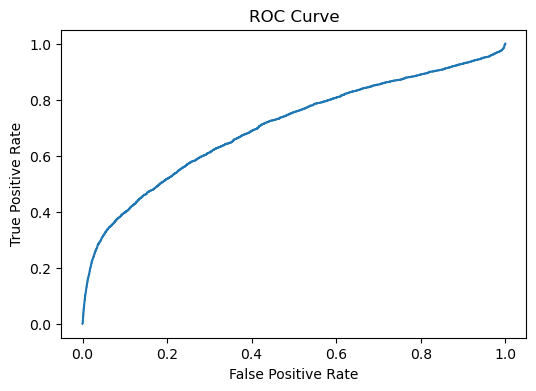

In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# Confusion Matrix

Confusion Matrix summarizes classification performance by showing:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)

It helps evaluate classification errors.

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

print(cm)

[[41878   114]
 [ 2854   154]]


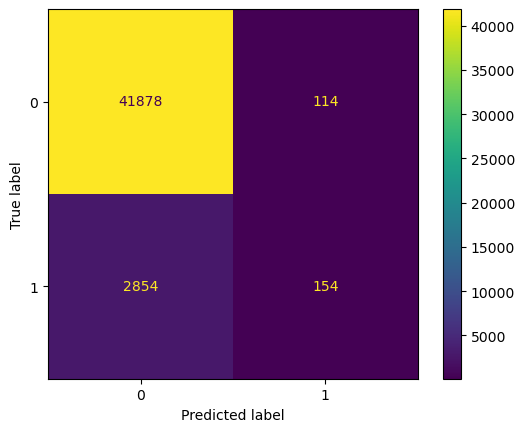

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
plt.show()

## Conclusion

The Logistic Regression credit risk model was successfully validated on an unseen validation dataset.

Key observations:

- Validation AUC (0.7039) is slightly higher than Training AUC (0.6879).
- Validation KS Statistic (0.3220) is comparable to Training KS Statistic (0.3093).
- The model demonstrates stable performance across datasets.
- No significant evidence of overfitting was observed.

Therefore, the model is considered suitable for credit risk prediction and further deployment activities.